# Packages

In [1]:
%load_ext rpy2.ipython

In [2]:
%%R
library(survival)
# library(survminer)
library(prodlim)

In [3]:
import sys
sys.path.append('/home/boscoll/github/Machine-learning-scripts')
sys.path.append('/home/boscoll/github/RNAseq-scripts')
from sklearn_surv_utils import *
from utils import *
from functions_RNAseq import * 
from survival_functions import *
from sksurv.nonparametric import kaplan_meier_estimator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline, Pipeline
import seaborn as sns
import pickle
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw,cumulative_dynamic_auc
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
from sksurv.svm import FastSurvivalSVM
from scipy.stats import rankdata
from scipy.stats import mannwhitneyu
from scipy.stats import fisher_exact, mannwhitneyu, chisquare, chi2_contingency
import glob
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = ['Helvetica']
from matplotlib import font_manager
font_manager.fontManager.addfont("/home/boscoll/Helvetica.ttc")

In [4]:
#palette ccne1 amp 
palette = {1:'#edb422', 0:'#004f7c'}

# Load data

In [5]:
ccne1_cohort = pd.read_csv('/home/boscoll/Projects/ccne1/data/4_may/ccne1_cohort.csv', index_col=0)
facets_sample_level = pd.read_csv('/home/boscoll/Projects/ccne1/data/4_may/facets_biomarkers.csv', index_col=0)
alt_matrix = pd.read_csv('/home/boscoll/Projects/ccne1/data/4_may/alt_matrix.csv', index_col=0)

In [6]:
#sigma
sigma = pd.read_csv('/home/boscoll/Projects/ccne1/data/sigma/96matrix_output_tumortype_breast_platform_MSK-IMPACT410Genes_cf0_lite.csv', index_col=0)
sigma['categ'] = ['APOBEC' if i == "Signature_APOBEC" else 'HRD' if i in ['Signature_3_hc', 'Signature_3_lc'] else 'Clock' if i == "Signature_clock" else 'Other' for i in sigma.categ]

In [7]:
#1L 
cdk_1L = pd.read_csv('/home/boscoll/Projects/ccne1/data/cdk46_1L/cdk_1L_survival_data.csv', index_col=0).query('Time > 0') 
her2_1L = pd.read_csv('/home/boscoll/Projects/ccne1/data/her2_1L/her2_1L_survival_data.csv', index_col=0).query('Time > 0')
tnbc_1L = pd.read_csv('/home/boscoll/Projects/ccne1/data/tnbc_1L/tnbc_1L_survival_data.csv', index_col=0).query('Time > 0')

In [8]:
alt_matrix = pd.read_csv('/home/boscoll/Projects/ccne1/data/4_may/alt_matrix.csv', index_col=0)
tp53 = alt_matrix[['TP53_tsg']]

In [9]:
#id of patients with CCNE1 amplification by pipeline of MSK-IMPACT but not satisfying criteria for amplification by FACETS calling (tcn ≥5 without WGD or tcn ≥6 and WGD)
id_pipeline_only = pd.read_csv('/home/boscoll/Projects/ccne1/data/4_may/id_only_pipeline_samples.csv', index_col=0).index.tolist()

# Analysis

## CDK4/6i+ET

In [10]:
print('nr of patients treated with CDK in 1L: ', cdk_1L.index.nunique())
print('nr of cases with ccne1 amplification: ', cdk_1L.loc[cdk_1L['ccne1_amp'] == 1].index.nunique())

nr of patients treated with CDK in 1L:  1037
nr of cases with ccne1 amplification:  15


In [11]:
%%R -i cdk_1L
print(survfit(Surv(Time, Event) ~ 1, data = cdk_1L))
print(survfit(Surv(Time, Event) ~ ccne1_amp, data = cdk_1L))
print(summary(coxph(Surv(Time, Event) ~ ccne1_amp, data = cdk_1L)))

Call: survfit(formula = Surv(Time, Event) ~ 1, data = cdk_1L)

        n events median 0.95LCL 0.95UCL
[1,] 1037    708   18.3    16.8    19.7
Call: survfit(formula = Surv(Time, Event) ~ ccne1_amp, data = cdk_1L)

               n events median 0.95LCL 0.95UCL
ccne1_amp=0 1022    695   18.3   16.98    20.5
ccne1_amp=1   15     13   13.1    8.87      NA
Call:
coxph(formula = Surv(Time, Event) ~ ccne1_amp, data = cdk_1L)

  n= 1037, number of events= 708 

            coef exp(coef) se(coef)     z Pr(>|z|)
ccne1_amp 0.3971    1.4875   0.2802 1.417    0.156

          exp(coef) exp(-coef) lower .95 upper .95
ccne1_amp     1.487     0.6723    0.8589     2.576

Concordance= 0.503  (se = 0.002 )
Likelihood ratio test= 1.78  on 1 df,   p=0.2
Wald test            = 2.01  on 1 df,   p=0.2
Score (logrank) test = 2.03  on 1 df,   p=0.2



1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


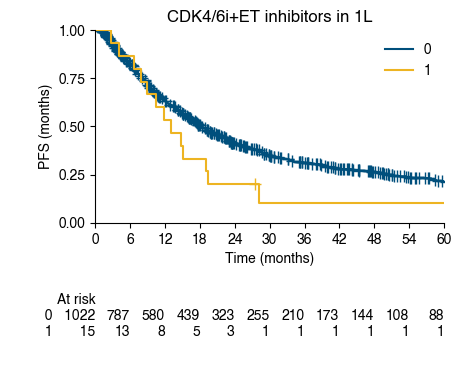

In [38]:
plot_kaplan_meier_risktable(cdk_1L, 'ccne1_amp', colors = palette, ylabel = 'PFS (months)', title = 'CDK4/6i+ET inhibitors in 1L', upper_limit=60, step=6, figsize=(4.5, 2.5), only_risk=True,
                            save = '/home/boscoll/Projects/ccne1/results/figures/fig_4/cdk_1L_km_risk.pdf'
                            )

In [13]:
%%R -i cdk_1L
#clinical benefit rate
fit = survfit(Surv(Time, Event) ~ ccne1_amp, data = cdk_1L)
summary(fit, times = 24)

Call: survfit(formula = Surv(Time, Event) ~ ccne1_amp, data = cdk_1L)

                ccne1_amp=0 
        time       n.risk      n.event     survival      std.err lower 95% CI 
     24.0000     323.0000     546.0000       0.4103       0.0165       0.3793 
upper 95% CI 
      0.4439 

                ccne1_amp=1 
        time       n.risk      n.event     survival      std.err lower 95% CI 
     24.0000       3.0000      12.0000       0.2000       0.1033       0.0727 
upper 95% CI 
      0.5503 



1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


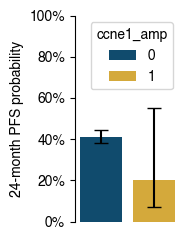

In [39]:
# Call: survfit(formula = Surv(Time, Event) ~ ccne1_amp, data = cdk_1L)

#                 ccne1_amp=0 
#         time       n.risk      n.event     survival      std.err lower 95% CI 
#      24.0000     323.0000     546.0000       0.4103       0.0165       0.3793 
# upper 95% CI 
#       0.4439 

#                 ccne1_amp=1 
#         time       n.risk      n.event     survival      std.err lower 95% CI 
#      24.0000       3.0000      12.0000       0.2000       0.1033       0.0727 
# upper 95% CI 
#       0.5503 

pfs_rate = pd.DataFrame({'ccne1_amp': [0, 1], 'PFS_24_months': [0.4103, 0.2], 'CI_Lower': [0.3793, 0.0727], 'CI_Upper': [0.4439, 0.5503]})
_, (ax1) = plt.subplots(1, 1, figsize=(2, 2.5))
sns.barplot(x='ccne1_amp', y='PFS_24_months', data=pfs_rate, hue='ccne1_amp', palette=palette, errorbar=None, ax=ax1, width=0.8)
ax1.errorbar(x=[0, 1], y=pfs_rate['PFS_24_months'], yerr=[pfs_rate['PFS_24_months'] - pfs_rate['CI_Lower'], pfs_rate['CI_Upper'] - pfs_rate['PFS_24_months']], fmt='none', c='black', capsize=5)
ax1.set_ylim(0, 1)
ax1.set_ylabel('24-month PFS probability')
ax1.set_xlabel('')
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax1.set_xticklabels(['', ''])
ax1.set_xticks([])
sns.despine(trim = True, bottom = True)
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_4/cdk_pfs_rate_24_months.pdf', bbox_inches='tight')
plt.show()

***tcn_em levels and PFS --> univariable cox regression among CCNE1 amplified tumors using tcn as continuous***

In [108]:
cdk_level_amp = cdk_1L.loc[cdk_1L["ccne1_amp"] == 1].join(ccne1_cohort.drop(columns='ccne1_amp'))

In [109]:
%%R -i cdk_level_amp
summary(coxph(Surv(Time, Event) ~ tcn_em, data = cdk_level_amp))

Call:
coxph(formula = Surv(Time, Event) ~ tcn_em, data = cdk_level_amp)

  n= 15, number of events= 13 

          coef exp(coef) se(coef)     z Pr(>|z|)
tcn_em 0.06451   1.06664  0.05302 1.217    0.224

       exp(coef) exp(-coef) lower .95 upper .95
tcn_em     1.067     0.9375    0.9614     1.183

Concordance= 0.578  (se = 0.063 )
Likelihood ratio test= 1.2  on 1 df,   p=0.3
Wald test            = 1.48  on 1 df,   p=0.2
Score (logrank) test = 1.62  on 

1 df,   p=0.2



## HER2 1L

In [20]:
print('nr of patients treated with HER2 in 1L: ', her2_1L.index.nunique())
print('nr of cases with ccne1 amplification: ', her2_1L.loc[her2_1L['ccne1_amp'] == 1].index.nunique())

nr of patients treated with HER2 in 1L:  316
nr of cases with ccne1 amplification:  18


In [21]:
%%R -i her2_1L
print(survfit(Surv(Time, Event) ~ 1, data = her2_1L))
print(survfit(Surv(Time, Event) ~ ccne1_amp, data = her2_1L))
summary(coxph(Surv(Time, Event) ~ ccne1_amp, data = her2_1L))

Call: survfit(formula = Surv(Time, Event) ~ 1, data = her2_1L)

       n events median 0.95LCL 0.95UCL
[1,] 316    166   17.2    14.3    23.7
Call: survfit(formula = Surv(Time, Event) ~ ccne1_amp, data = her2_1L)

              n events median 0.95LCL 0.95UCL
ccne1_amp=0 298    153  18.04   14.72    24.6
ccne1_amp=1  18     13   8.41    6.37      NA
Call:
coxph(formula = Surv(Time, Event) ~ ccne1_amp, data = her2_1L)

  n= 316, number of events= 166 

            coef exp(coef) se(coef)     z Pr(>|z|)   
ccne1_amp 0.8446    2.3270   0.2918 2.895   0.0038 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

          exp(coef) exp(-coef) lower .95 upper .95
ccne1_amp     2.327     0.4297     1.313     4.123

Concordance= 0.526  (se = 0.012 )
Likelihood ratio test= 6.71  on 1 df,   p=0.01
Wald test            = 8.38  on 1 df,   p=0.004
Score (logrank) test = 8.89  on 1 df,   p=0.003



1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


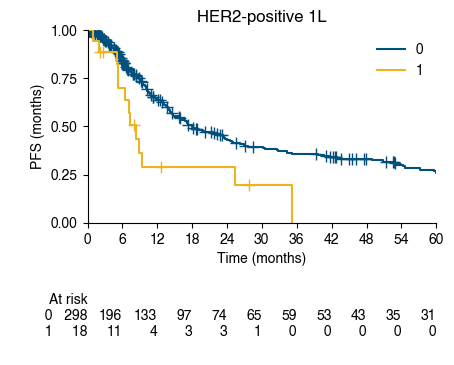

In [40]:
plot_kaplan_meier_risktable(her2_1L, 'ccne1_amp', colors = palette, ylabel = 'PFS (months)', title = 'HER2-positive 1L', upper_limit=60, step=6, figsize=(4.5, 2.5), only_risk=True,
                            save = '/home/boscoll/Projects/ccne1/results/figures/fig_4/her2_1L_km_risk.pdf'
                            )

***tcn_em levels and PFS in HER2+***

In [113]:
her2_level_amp = her2_1L.loc[her2_1L["ccne1_amp"] == 1].join(ccne1_cohort.drop(columns='ccne1_amp'))

In [114]:
%%R -i her2_level_amp
print(coxph(Surv(Time, Event) ~ tcn_em, data = her2_level_amp))  

Call:
coxph(formula = Surv(Time, Event) ~ tcn_em, data = her2_level_amp)

          coef exp(coef) se(coef)      z     p
tcn_em -0.0185    0.9817   0.0598 -0.309 0.757

Likelihood ratio test=0.1  on 1 df, p=0.7515
n= 18, number of events= 13 


***ccne1 prognostication once adjusted for wgd and fga***

In [68]:
df_stats = her2_1L.join(facets_sample_level[['wgd', 'fga']].assign(wgd = lambda x: x.wgd.astype(int)))
df_stats = df_stats.assign(fga = lambda x: x.fga * 10)
df_stats = df_stats.pipe(cox_regression).sort_values('p_value')
df_stats.reset_index(inplace=True)
df_stats

,covariate,hazard_ratio,ci_lower_95,ci_upper_95,p_value,log2_p_value
0,ccne1_amp,1.9406,1.0825,3.4792,0.026015,-5.2645
1,fga,1.0932,0.9956,1.2003,0.061735,-4.0178
2,wgd,1.0511,0.6941,1.5916,0.814043,-0.2968


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


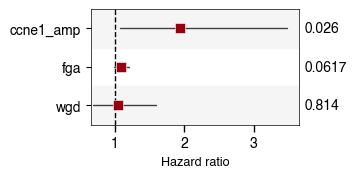

In [69]:
# position and palette
ypos = np.arange(len(df_stats))  # one y per row
df_stats['ypos'] = ypos

fig, ax = plt.subplots(figsize=(3,1.5))

# light alternating background bands for every row of the plot
for i in range(len(df_stats)):
    if i % 2 == 0:
        ax.axhspan(i-0.5, i+0.5, color='0.96', zorder=0)
ax.axvline(1, ls='--', lw=1, color='black', zorder=1)


for _, r in df_stats.iterrows():
    # CI bar
    ax.plot([r['ci_lower_95'], r['ci_upper_95']], [r['ypos'], r['ypos']],
            color='0.25', lw=1, solid_capstyle='round', zorder=2)
    # square marker at HR
    ax.scatter(r['hazard_ratio'], r['ypos'],
               s=50, marker='s',
               color= '#99000d',
               edgecolor='white', linewidth=0.4,
               zorder=3)

# y axis
ax.set_yticks(ypos)
ax.set_ylim(-0.5, len(df_stats)-0.5)
ax.set_yticklabels(df_stats['covariate'])
ax.invert_yaxis()  
ax.grid(False)


# x axis
ax.set_xticklabels([0.5, 1, 2, 3, 4, 5])
ax.tick_params(axis='x',
               which='major',
               bottom=True, top=False,    
               length=5, width=1,         
               direction='out')
ax.set_xlabel('Hazard ratio', fontsize=9)

# major axis
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_color('black')

# x range
xmin = max(0.1, df_stats['ci_lower_95'].min()*0.95)
xmax = df_stats['ci_upper_95'].max()*1.05
ax.set_xlim(xmin, xmax)
ax.set_xlabel('Hazard ratio')
ax.set_ylabel('')

# p values
for _, r in df_stats.iterrows():
    ax.text(xmax*1.02, r['ypos'], f"{r['p_value']:.3g}",
            va='center', ha='left',
            fontweight='bold' if r['p_value'] < 0.05 else 'normal',
            )

plt.subplots_adjust(right=0.82)

plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_4/multivariable_forest_plot.pdf', bbox_inches='tight')
plt.show()

***ccne1 prognostication once adjusted for TP53 status***

In [26]:
her2_1L.join(tp53).fillna(0).pipe(cox_regression)

,hazard_ratio,ci_lower_95,ci_upper_95,p_value,log2_p_value
covariate,,,,,
ccne1_amp,2.0765,1.1562,3.7291,0.014449,-6.1129
TP53_tsg,1.3091,0.9498,1.8044,0.099928,-3.3230


           hazard_ratio  ci_lower_95  ci_upper_95   p_value  log2_p_value
covariate                                                                
ccne1_amp        2.0635       1.1484       3.7081  0.015411       -6.0199
TP53_tsg         1.1503       0.8084       1.6366  0.436550       -1.1958


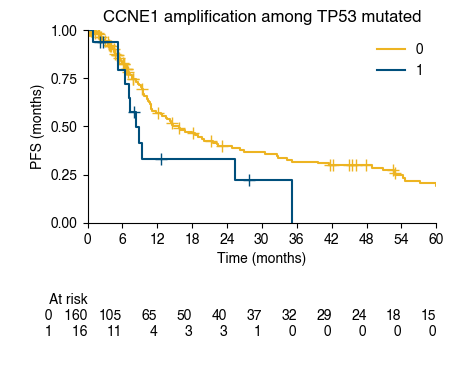

In [34]:
print(her2_1L.join(tp53).pipe(cox_regression))
her2_1L.join(tp53).query('TP53_tsg == 1').pipe(plot_kaplan_meier_risktable, 'ccne1_amp', title='CCNE1 amplification among TP53 mutated', colors = palette, ylabel = 'PFS (months)', upper_limit=60, step=6, figsize=(4.5, 2.5), only_risk=True)
tp53_her2 = her2_1L.join(tp53).query('TP53_tsg == 1')

In [35]:
%%R -i tp53_her2
print(survfit(Surv(Time, Event) ~ ccne1_amp, data = tp53_her2))
summary(coxph(Surv(Time, Event) ~ ccne1_amp, data = tp53_her2))

Call: survfit(formula = Surv(Time, Event) ~ ccne1_amp, data = tp53_her2)

              n events median 0.95LCL 0.95UCL
ccne1_amp=0 160     91  15.74   11.07    22.5
ccne1_amp=1  16     11   8.41    7.19      NA
Call:
coxph(formula = Surv(Time, Event) ~ ccne1_amp, data = tp53_her2)

  n= 176, number of events= 102 

            coef exp(coef) se(coef)     z Pr(>|z|)  
ccne1_amp 0.5990    1.8202   0.3236 1.851   0.0642 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

          exp(coef) exp(-coef) lower .95 upper .95
ccne1_amp      1.82     0.5494    0.9652     3.433

Concordance= 0.525  (se = 0.016 )
Likelihood ratio test= 2.96  on 1 df,   p=0.09
Wald test            = 3.42  on 1 df,   p=0.06
Score (logrank) test = 3.53  on 1 df,   p=0.06



## TNBC 1L

In [10]:
print('nr of patients treated with TNBC in 1L: ', tnbc_1L.index.nunique())
print('nr of cases with ccne1 amplification: ', tnbc_1L.loc[tnbc_1L['ccne1_amp'] == 1].index.nunique())

nr of patients treated with TNBC in 1L:  543
nr of cases with ccne1 amplification:  34


In [18]:
%%R -i tnbc_1L
print(survfit(Surv(Time, Event) ~ 1, data = tnbc_1L))
print(survfit(Surv(Time, Event) ~ ccne1_amp, data = tnbc_1L))
summary(coxph(Surv(Time, Event) ~ ccne1_amp, data = tnbc_1L))

Call: survfit(formula = Surv(Time, Event) ~ 1, data = tnbc_1L)

       n events median 0.95LCL 0.95UCL
[1,] 543    400   4.14    3.68    4.86
Call: survfit(formula = Surv(Time, Event) ~ ccne1_amp, data = tnbc_1L)

              n events median 0.95LCL 0.95UCL
ccne1_amp=0 509    375   4.50    3.75    5.29
ccne1_amp=1  34     25   3.29    2.56    4.27
Call:
coxph(formula = Surv(Time, Event) ~ ccne1_amp, data = tnbc_1L)

  n= 543, number of events= 400 

            coef exp(coef) se(coef)     z Pr(>|z|)  
ccne1_amp 0.3587    1.4314   0.2078 1.726   0.0843 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

          exp(coef) exp(-coef) lower .95 upper .95
ccne1_amp     1.431     0.6986    0.9526     2.151

Concordance= 0.512  (se = 0.006 )
Likelihood ratio test= 2.69  on 1 df,   p=0.1
Wald test            = 2.98  on 1 df,   p=0.08
Score (logrank) test = 3.01  on 1 df,   p=0.08



1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


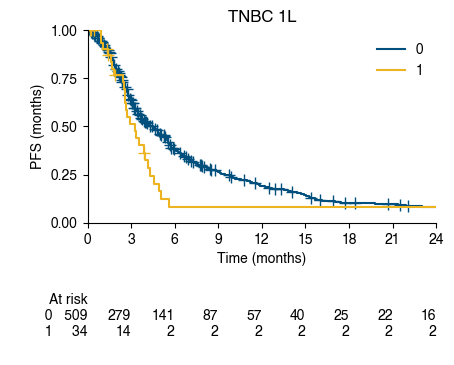

In [41]:
plot_kaplan_meier_risktable(tnbc_1L, 'ccne1_amp', colors = palette, ylabel = 'PFS (months)', title = 'TNBC 1L', upper_limit=24, step=3, figsize=(4.5, 2.5), only_risk=True,
                            save = '/home/boscoll/Projects/ccne1/results/figures/fig_4/tnbc_1L_km_risk.pdf'
                            )

In [15]:
%%R -i tnbc_1L
#clinical benefit rate
fit = survfit(Surv(Time, Event) ~ ccne1_amp, data = tnbc_1L)
summary(fit, times = 6)

Call: survfit(formula = Surv(Time, Event) ~ ccne1_amp, data = tnbc_1L)

                ccne1_amp=0 
        time       n.risk      n.event     survival      std.err lower 95% CI 
      6.0000     141.0000     274.0000       0.3804       0.0237       0.3367 
upper 95% CI 
      0.4298 

                ccne1_amp=1 
        time       n.risk      n.event     survival      std.err lower 95% CI 
      6.0000       2.0000      25.0000       0.0810       0.0544       0.0217 
upper 95% CI 
      0.3023 



1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


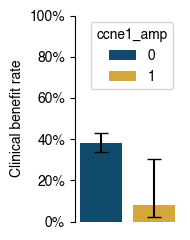

In [42]:
# Call: survfit(formula = Surv(Time, Event) ~ ccne1_amp, data = tnbc_1L)

#                 ccne1_amp=0 
#         time       n.risk      n.event     survival      std.err lower 95% CI 
#       6.0000     141.0000     274.0000       0.3804       0.0237       0.3367 
# upper 95% CI 
#       0.4298 

#                 ccne1_amp=1 
#         time       n.risk      n.event     survival      std.err lower 95% CI 
#       6.0000       2.0000      25.0000       0.0810       0.0544       0.0217 
# upper 95% CI 
#       0.3023 

pfs_rate = pd.DataFrame({'ccne1_amp': [0, 1], 'PFS_6_months': [0.3804, 0.0810], 'CI_Lower': [0.3367, 0.0217], 'CI_Upper': [0.4298, 0.3023]})
_, (ax1) = plt.subplots(1, 1, figsize=(2, 2.5))
sns.barplot(x='ccne1_amp', y='PFS_6_months', data=pfs_rate, hue='ccne1_amp', palette=palette, errorbar=None, ax=ax1, width=0.8)
ax1.errorbar(x=[0, 1], y=pfs_rate['PFS_6_months'], yerr=[pfs_rate['PFS_6_months'] - pfs_rate['CI_Lower'], pfs_rate['CI_Upper'] - pfs_rate['PFS_6_months']], fmt='none', c='black', capsize=5)
ax1.set_ylim(0, 1)
ax1.set_ylabel('Clinical benefit rate')
ax1.set_xlabel('')
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax1.set_xticklabels(['', ''])
ax1.set_xticks([])
sns.despine(trim = True, bottom = True)
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_4/tnbc_pfs_rate_6_months.pdf', bbox_inches='tight')
plt.show()

***Stratified per ICI***

In [11]:
ids_ici = pd.read_csv('/home/boscoll/Projects/ccne1/data/tnbc_1L/tnbc_1L_regimens.csv', index_col=0).query('ICI == 1')
tnbc_1L_ici = tnbc_1L.loc[tnbc_1L.index.isin(ids_ici.index)]
print(f'nr samples treated with ICI: {tnbc_1L_ici.shape[0]}')

nr samples treated with ICI: 91


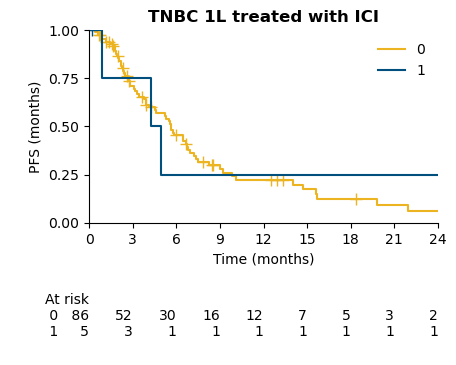

In [121]:
plot_kaplan_meier_risktable(tnbc_1L_ici, 'ccne1_amp', colors = palette, ylabel = 'PFS (months)', title = 'TNBC 1L treated with ICI', upper_limit=24, step=3, figsize=(4.5, 2.5), only_risk=True)

**non ICI**

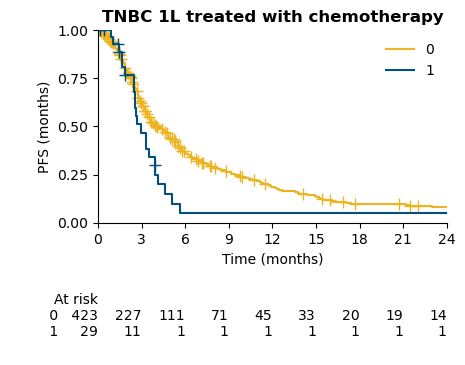

In [122]:
tnbc_1L_chemo = tnbc_1L.loc[~tnbc_1L.index.isin(ids_ici.index)]
plot_kaplan_meier_risktable(tnbc_1L_chemo, 'ccne1_amp', colors = palette, ylabel = 'PFS (months)', title = 'TNBC 1L treated with chemotherapy', upper_limit=24, step=3, figsize=(4.5, 2.5), only_risk=True)

***tcn_em levels and PFS in TNBC+***

In [123]:
tnbc_level_amp = tnbc_1L.loc[tnbc_1L["ccne1_amp"] == 1].join(ccne1_cohort.drop(columns='ccne1_amp'))

In [124]:
%%R -i tnbc_level_amp
print(coxph(Surv(Time, Event) ~ tcn_em, data = tnbc_level_amp))

Call:
coxph(formula = Surv(Time, Event) ~ tcn_em, data = tnbc_level_amp)

            coef exp(coef)  se(coef)      z     p
tcn_em -0.007299  0.992727  0.033558 -0.218 0.828

Likelihood ratio test=0.05  on 1 df, p=0.8267
n= 34, number of events= 25 


***ccne1 prognostication once adjusted for wgd and fga***

In [125]:
df_stats = tnbc_1L.join(facets_sample_level[['wgd', 'fga']].assign(wgd = lambda x: x.wgd.astype(int)))
df_stats.pipe(cox_regression).sort_values('p_value')

,hazard_ratio,ci_lower_95,ci_upper_95,p_value,log2_p_value
covariate,,,,,
fga,1.3834,0.7703,2.4844,0.277315,-1.8504
ccne1_amp,1.2212,0.8054,1.8517,0.346705,-1.5282
wgd,1.0764,0.8362,1.3856,0.567651,-0.8169


***ccne1 prognostication once adjusted for TP53 status***

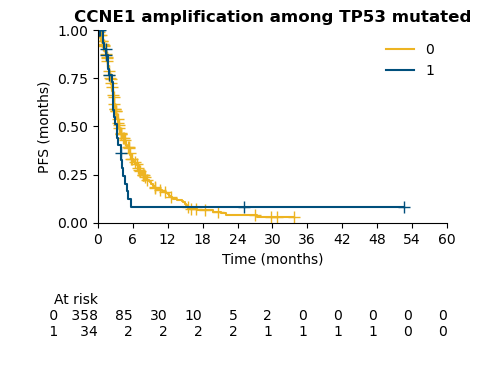

In [126]:
tnbc_1L.join(tp53).query('TP53_tsg == 1').pipe(plot_kaplan_meier_risktable, 'ccne1_amp', title='CCNE1 amplification among TP53 mutated', colors = palette, ylabel = 'PFS (months)', upper_limit=60, step=6, figsize=(4.5, 2.5), only_risk=True)